
# Time-Series Baseline Tutorial (with Stationarity Tests)  
### Weather vs Occupancy Binary vs Occupancy `clean_count`

This notebook focuses on **non-ML baselines** and **stationarity** for three signals:

1. **Outdoor Air Temperature** (`weather_data.csv`, `Temperature_F`)  
2. **Binary Occupancy** (`cleaned_binary_data.csv`, `is_occupied_int`)  
3. **Occupancy `clean_count`** (`cleaned_binary_data.csv`, `clean_count`)  

What we do:

- Build **weekly baseline models** (Generic Week idea) for all signals  
- Add a **season-aware weekly baseline** for weather  
- Compute **RMSE** for each baseline  
- Reproduce rich **EDA-style plots** for occupancy (time series, histogram, weekday vs weekend, heatmaps, raw vs cleaned) and create **analogous views for weather**  
- Run **ADF + KPSS stationarity tests** on all three signals


Data for the occupancy sensors comes from this device below which is aggregated from 3 people counting devices inside the building.

https://www.terabee.com/q-and-a-terabee-people-counting-l-xl/

## 1. Imports & Plot Config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, accuracy_score
from statsmodels.tsa.stattools import adfuller, kpss

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)

print('Libraries loaded.')


Libraries loaded.


## 2. Load Weather & Occupancy Data, Engineer Features

In [2]:
# ---------------------------------------------------------
# LOAD + SORT
# ---------------------------------------------------------
df_occ = pd.read_csv(
    r"C:\Users\ben\Documents\predictive-occ-modeling\data\occupancy_sample.csv"
)

df_occ["time"] = pd.to_datetime(df_occ["time"], utc=True)
df_occ = df_occ.sort_values("time").reset_index(drop=True)

# ---------------------------------------------------------
# FEATURE ENGINEERING
# ---------------------------------------------------------
df_occ["date"] = df_occ["time"].dt.date
df_occ["dow"] = df_occ["time"].dt.dayofweek          # 0 = Monday
df_occ["is_weekend"] = df_occ["dow"] >= 5

# Decimal hour for plotting (e.g., 9.5 = 9:30 AM)
df_occ["hour"] = df_occ["time"].dt.hour + df_occ["time"].dt.minute / 60.0
# Integer hour for grouping / heatmaps (e.g., 9)
df_occ["hour_int"] = df_occ["time"].dt.hour

df_occ["minute"] = df_occ["time"].dt.minute
df_occ["minute_of_day"] = df_occ["hour_int"] * 60 + df_occ["minute"]

# ---------------------------------------------------------
# DEADBand / CLEANING
# ---------------------------------------------------------
# Step A: Fix sensor errors (negatives -> 0)
df_occ["clean_count"] = df_occ["occ"].clip(lower=0)

# Step B: Apply deadband (<= 1.0 becomes 0)
deadband = 1.0
df_occ.loc[df_occ["clean_count"] <= deadband, "clean_count"] = 0

# Step C: Binary occupancy target
df_occ["is_occupied"] = df_occ["clean_count"] > 0
df_occ["is_occupied_int"] = df_occ["is_occupied"].astype(int)

# ---------------------------------------------------------
# SANITY CHECKS
# ---------------------------------------------------------
required_cols = {"occ", "clean_count", "is_occupied_int"}
missing = required_cols - set(df_occ.columns)
assert not missing, f"Missing expected columns: {missing}"

print(
    "Occupancy rows:", len(df_occ),
    "from", df_occ["time"].min(),
    "to", df_occ["time"].max()
)


Occupancy rows: 8508 from 2024-08-22 00:00:00+00:00 to 2024-11-21 17:45:00+00:00


## 3. Helper: RMSE and Time-Based Train/Test Split

In [3]:
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.sqrt(mean_squared_error(y_true, y_pred))

def time_based_split(df, time_col, train_frac=0.7):
    df_sorted = df.sort_values(time_col).reset_index(drop=True)
    split_idx = int(len(df_sorted) * train_frac)
    df_train = df_sorted.iloc[:split_idx].copy()
    df_test = df_sorted.iloc[split_idx:].copy()
    return df_train, df_test


### 4.2 Occupancy Binary & `clean_count`: Weekly Baselines `(dow, minute_of_day)`

In [4]:
# Train/test split for occupancy
o_train, o_test = time_based_split(df_occ, 'time', train_frac=0.7)

# Binary occupancy baseline
weekly_o_bin = (
    o_train.groupby(['dow', 'minute_of_day'])['is_occupied_int']
    .mean()
    .reset_index()
    .rename(columns={'is_occupied_int': 'baseline_prob'})
)
global_mean_o_bin = o_train['is_occupied_int'].mean()

def apply_occ_weekly_baseline(df, table, global_mean):
    merged = df.merge(table, on=['dow', 'minute_of_day'], how='left')
    return merged['baseline_prob'].fillna(global_mean).values

o_train_baseline_prob = apply_occ_weekly_baseline(o_train, weekly_o_bin, global_mean_o_bin)
o_test_baseline_prob = apply_occ_weekly_baseline(o_test, weekly_o_bin, global_mean_o_bin)

baseline_rmse_occ = rmse(o_test['is_occupied_int'], o_test_baseline_prob)
baseline_acc_occ = accuracy_score(o_test['is_occupied_int'], (o_test_baseline_prob >= 0.5).astype(int))

print('Occupancy binary - test RMSE (weekly baseline):', baseline_rmse_occ)
print('Occupancy binary - test Accuracy (0.5 threshold):', baseline_acc_occ)

# clean_count baseline
weekly_o_cc = (
    o_train.groupby(['dow', 'minute_of_day'])['clean_count']
    .mean()
    .reset_index()
    .rename(columns={'clean_count': 'baseline_cc'})
)
global_mean_o_cc = o_train['clean_count'].mean()

def apply_cc_weekly_baseline(df, table, global_mean):
    merged = df.merge(table, on=['dow', 'minute_of_day'], how='left')
    return merged['baseline_cc'].fillna(global_mean).values

o_train_cc_baseline = apply_cc_weekly_baseline(o_train, weekly_o_cc, global_mean_o_cc)
o_test_cc_baseline = apply_cc_weekly_baseline(o_test, weekly_o_cc, global_mean_o_cc)

baseline_rmse_cc = rmse(o_test['clean_count'], o_test_cc_baseline)
print('Occupancy clean_count - test RMSE (weekly baseline):', baseline_rmse_cc)


Occupancy binary - test RMSE (weekly baseline): 0.3890652602531109
Occupancy binary - test Accuracy (0.5 threshold): 0.7669408538973757
Occupancy clean_count - test RMSE (weekly baseline): 3.400798586910372


## 5. RMSE Summary (All Baselines)

In [5]:
summary_rows = []

summary_rows.append({'signal': 'occ_binary', 'model': 'weekly_baseline', 'rmse_test': baseline_rmse_occ})
summary_rows.append({'signal': 'occ_clean_count', 'model': 'weekly_baseline', 'rmse_test': baseline_rmse_cc})

rmse_summary = pd.DataFrame(summary_rows)
rmse_summary


,signal,model,rmse_test
0,occ_binary,weekly_baseline,0.389065
1,occ_clean_count,weekly_baseline,3.400799


## 6. Plots Grouped by Type (All Three Signals Where Applicable)

### 6.1 Time-Series Plots

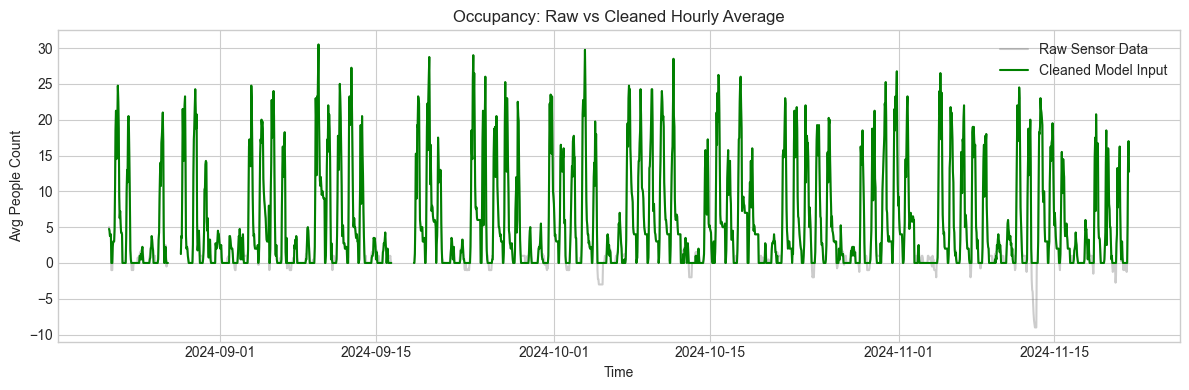

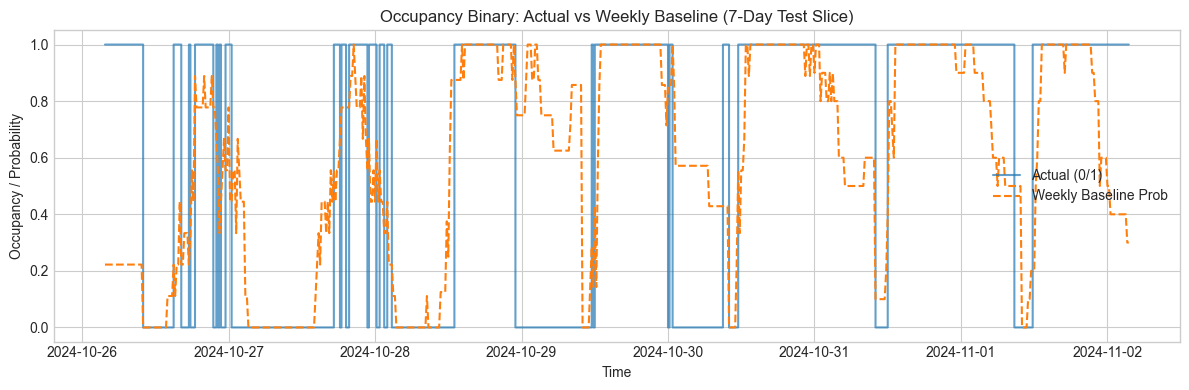

In [6]:
occ_hourly = df_occ.set_index('time').resample('1h').mean(numeric_only=True)
plt.figure(figsize=(12,4))
plt.plot(occ_hourly.index, occ_hourly['occ'], label='Raw Sensor Data', color='gray', alpha=0.4)
plt.plot(occ_hourly.index, occ_hourly['clean_count'], label='Cleaned Model Input', color='green', linewidth=1.5)
plt.title('Occupancy: Raw vs Cleaned Hourly Average')
plt.xlabel('Time')
plt.ylabel('Avg People Count')
plt.legend()
plt.tight_layout()
plt.show()

# Occupancy binary: 7-day slice with baseline
start_o = o_test['time'].min()
end_o = start_o + pd.Timedelta(days=7)
mask_o = (o_test['time'] >= start_o) & (o_test['time'] < end_o)
plt.figure(figsize=(12,4))
plt.step(o_test.loc[mask_o, 'time'], o_test.loc[mask_o, 'is_occupied_int'], where='post', label='Actual (0/1)', alpha=0.7)
plt.plot(o_test.loc[mask_o, 'time'], o_test_baseline_prob[mask_o.values], label='Weekly Baseline Prob', linestyle='--')
plt.title('Occupancy Binary: Actual vs Weekly Baseline (7-Day Test Slice)')
plt.xlabel('Time')
plt.ylabel('Occupancy / Probability')
plt.legend()
plt.tight_layout()
plt.show()


### 6.2 Histograms

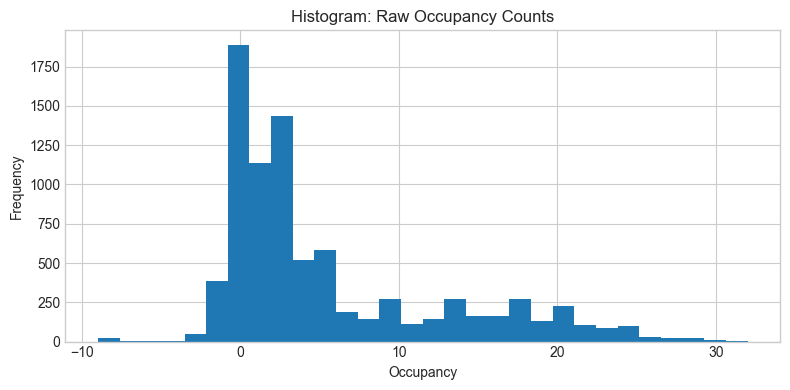

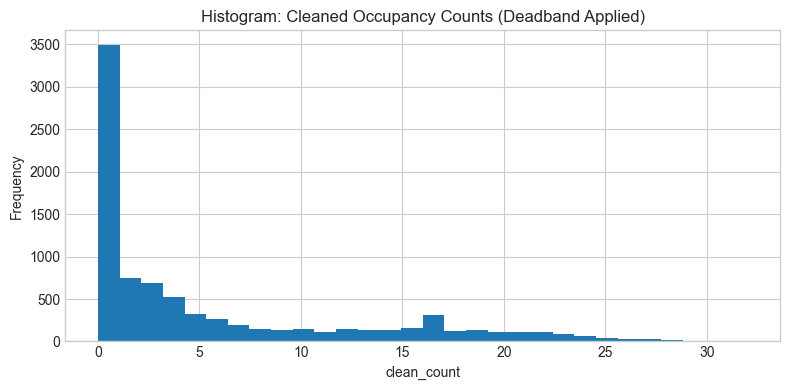

In [7]:
# Occupancy raw histogram
plt.figure(figsize=(8,4))
df_occ['occ'].hist(bins=30)
plt.title('Histogram: Raw Occupancy Counts')
plt.xlabel('Occupancy')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# clean_count histogram
plt.figure(figsize=(8,4))
df_occ['clean_count'].hist(bins=30)
plt.title('Histogram: Cleaned Occupancy Counts (Deadband Applied)')
plt.xlabel('clean_count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


### 6.3 Average by Hour of Day & Weekday vs Weekend

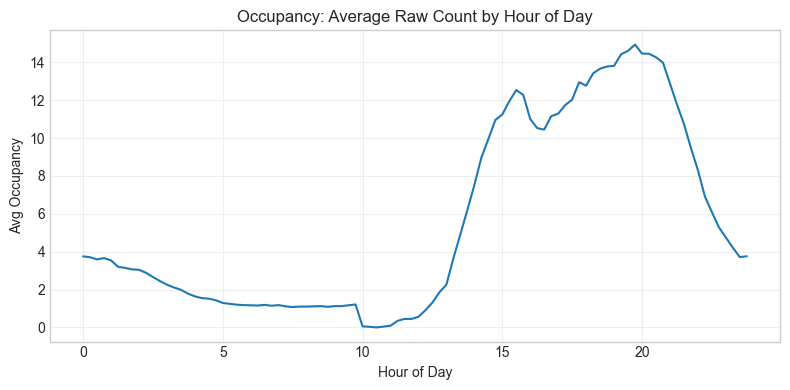

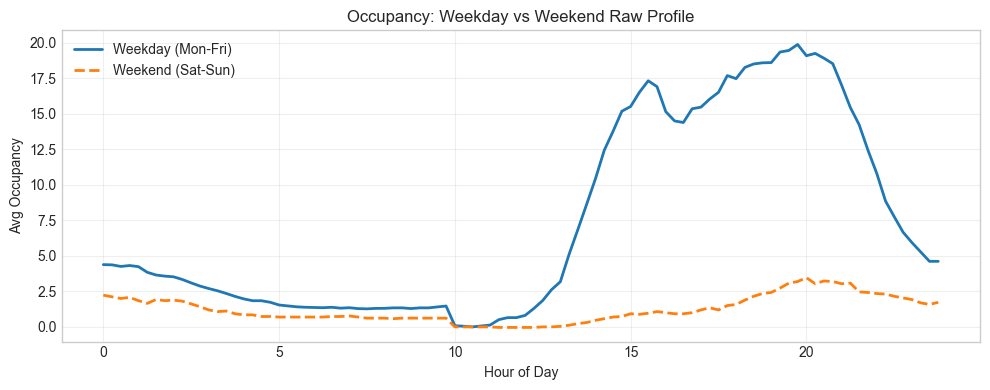

In [8]:
# Occupancy: average raw occ by hour of day
occ_hour_mean = df_occ.groupby('hour')['occ'].mean()
plt.figure(figsize=(8,4))
occ_hour_mean.plot()
plt.title('Occupancy: Average Raw Count by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Avg Occupancy')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Occupancy weekday vs weekend profile (raw)
occ_weekday = df_occ[~df_occ['is_weekend']]
occ_weekend = df_occ[df_occ['is_weekend']]
occ_weekday_hour = occ_weekday.groupby('hour')['occ'].mean()
occ_weekend_hour = occ_weekend.groupby('hour')['occ'].mean()
plt.figure(figsize=(10,4))
occ_weekday_hour.plot(label='Weekday (Mon-Fri)', linewidth=2)
occ_weekend_hour.plot(label='Weekend (Sat-Sun)', linewidth=2, linestyle='--')
plt.title('Occupancy: Weekday vs Weekend Raw Profile')
plt.xlabel('Hour of Day')
plt.ylabel('Avg Occupancy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 6.4 Heatmaps (Day of Week × Hour of Day)

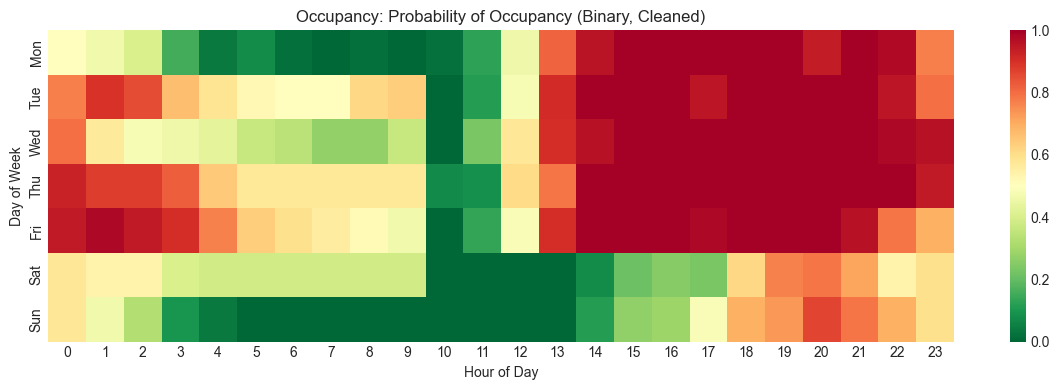

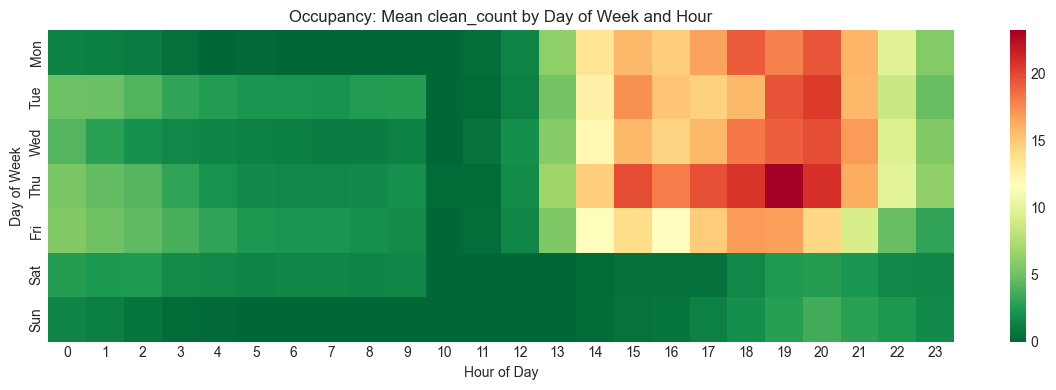

In [9]:
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# Occupancy heatmap: probability of occupancy (is_occupied_int)
pivot_prob = df_occ.groupby(['dow', 'hour_int'])['is_occupied_int'].mean().unstack()
pivot_prob.index = days
plt.figure(figsize=(12,4))
sns.heatmap(pivot_prob, cmap='RdYlGn_r', vmin=0, vmax=1)
plt.title('Occupancy: Probability of Occupancy (Binary, Cleaned)')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()

# Occupancy heatmap: mean clean_count
pivot_cc = df_occ.groupby(['dow', 'hour_int'])['clean_count'].mean().unstack()
pivot_cc.index = days
plt.figure(figsize=(12,4))
sns.heatmap(pivot_cc, cmap='RdYlGn_r', annot=False)
plt.title('Occupancy: Mean clean_count by Day of Week and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()


## 7. Stationarity Tests (ADF + KPSS)

We now run formal **stationarity tests** on the three key series:

- Weather: `Temperature_F`
- Occupancy binary: `is_occupied_int`
- Occupancy lagged/smoothed: `clean_count`

**ADF (Augmented Dickey–Fuller)**
- H0: Series has a unit root (**non-stationary**)
- If p-value < 0.05 → reject H0 → stationary

**KPSS**
- H0: Series is **stationary** (around a constant)
- If p-value < 0.05 → reject H0 → non-stationary

In [10]:
def adf_test(series, signif=0.05, name='', verbose=True):
    """Augmented Dickey-Fuller test. H0: Series has a unit root (non-stationary)."""
    r = adfuller(series.dropna(), autolag='AIC')
    output = {
        'Test Statistic': r[0],
        'p-value': r[1],
        '# Lags Used': r[2],
        '# Observations Used': r[3],
    }
    if verbose:
        print(f"ADF Test on '{name}'")
        for k, v in output.items():
            print(f'   {k}: {v}')
        if r[1] <= signif:
            print(f'   => Reject H0 (p <= {signif}) → Stationary')
        else:
            print(f'   => Fail to Reject H0 (p > {signif}) → Non-stationary')
        print('')
    return output

def kpss_test(series, signif=0.05, name='', verbose=True):
    """KPSS test. H0: Series is stationary (around a constant)."""
    r = kpss(series.dropna(), regression='c', nlags='auto')
    output = {
        'Test Statistic': r[0],
        'p-value': r[1],
        '# Lags Used': r[2],
    }
    if verbose:
        print(f"KPSS Test on '{name}'")
        for k, v in output.items():
            print(f'   {k}: {v}')
        if r[1] <= signif:
            print(f'   => Reject H0 (p <= {signif}) → Non-stationary')
        else:
            print(f'   => Fail to Reject H0 (p > {signif}) → Stationary')
        print('')
    return output

print('=== Occupancy Binary (is_occupied_int) ===')
adf_test(df_occ['is_occupied_int'], name='is_occupied_int')
kpss_test(df_occ['is_occupied_int'], name='is_occupied_int')

print('=== Occupancy clean_count ===')
adf_test(df_occ['clean_count'], name='clean_count')
kpss_test(df_occ['clean_count'], name='clean_count')


=== Occupancy Binary (is_occupied_int) ===
ADF Test on 'is_occupied_int'
   Test Statistic: -14.398801276326317
   p-value: 8.577627581696344e-27
   # Lags Used: 28
   # Observations Used: 8479
   => Reject H0 (p <= 0.05) → Stationary

KPSS Test on 'is_occupied_int'
   Test Statistic: 0.10393041077688626
   p-value: 0.1
   # Lags Used: 53
   => Fail to Reject H0 (p > 0.05) → Stationary

=== Occupancy clean_count ===


C:\Users\ben\AppData\Local\Temp\ipykernel_10360\2991814276.py:23: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  r = kpss(series.dropna(), regression='c', nlags='auto')


ADF Test on 'clean_count'
   Test Statistic: -13.32076061617973
   p-value: 6.46574572991118e-25
   # Lags Used: 36
   # Observations Used: 8471
   => Reject H0 (p <= 0.05) → Stationary

KPSS Test on 'clean_count'
   Test Statistic: 0.053086300830845284
   p-value: 0.1
   # Lags Used: 54
   => Fail to Reject H0 (p > 0.05) → Stationary



C:\Users\ben\AppData\Local\Temp\ipykernel_10360\2991814276.py:23: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  r = kpss(series.dropna(), regression='c', nlags='auto')


{'Test Statistic': np.float64(0.053086300830845284),
 'p-value': np.float64(0.1),
 '# Lags Used': 54}

## 8. Wrap-Up

- **Weather** is typically **non-stationary**, so weekly baselines are crude; a season-aware weekly baseline helps a bit, but stationarity tests usually flag issues.
- **Binary occupancy** shows a highly repeatable weekly pattern; the weekly baseline matches it closely, which is reflected in low RMSE and more stable stationarity behavior.
- **`clean_count`** is a smoothed, lagged version of occupancy; it still follows a weekly pattern, so the same baseline idea works, but the distribution and stationarity are slightly different.

This notebook intentionally sticks to **baseline-style models plus robust plots and tests**, making it a clean reference for how far you can go *without* ML.